In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="IXzKrxKhYSUYRyd5OJaN")
project = rf.workspace("norah-alshowair").project("using-phone-while-driving-qcvye-tjjun")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Using-phone-while-driving-1 in yolov8:: 100%|██████████| 4257/4257 [00:00<00:00, 5559.21it/s]


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

YOLO("yolov8n.pt").train(data=f"{dataset.location}/data.yaml", epochs=30, imgsz=640, batch=32)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Using-phone-while-driving-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7da48eee1320>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# from ultralytics import YOLO


model = YOLO('runs/detect/train/weights/best.pt')

# الآن شغّل التقييم
metrics = model.val()
print(f"mAP@50: {metrics.box.map50:.3f}")
print(f"mAP@50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2080.5±429.6 MB/s, size: 50.6 KB)
val: Scanning /content/Using-phone-while-driving-1/valid/labels.cache... 177 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 177/177 46.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.6it/s 3.3s
                   all        177        363      0.963      0.978      0.986      0.857
                 phone        177        186      0.927      0.957      0.978      0.793
                 wheel        177        177      0.998          1      0.995       0.92
Speed: 2.1ms preprocess, 4.6ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50: 0.986
mAP@50-95: 0.857



image 1/1 /content/img_11658 (1).jpg: 480x640 1 wheel, 7.0ms
Speed: 2.1ms preprocess, 7.0ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


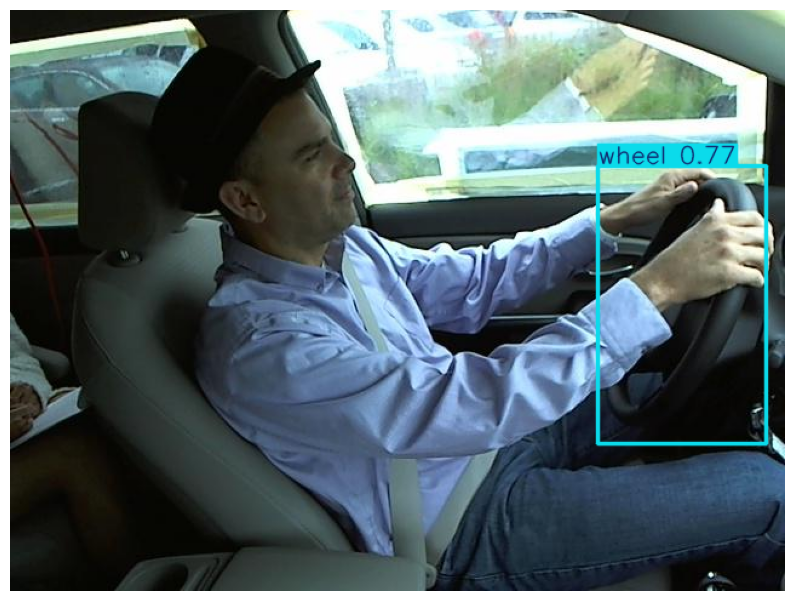

In [ ]:
results = model.predict(source='/content/img_11658 (1).jpg', conf=0.25, save=True)
import matplotlib.pyplot as plt
import cv2

# رسم النتيجة وعرضها
res_plotted = results[0].plot()
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()



In [ ]:
from google.colab import files

# تنزيل ملف النموذج الأفضل تلقائياً إلى جهازك
files.download('runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

# المسار الرئيسي لنتايج YOLO
detect_path = 'runs/detect'

if os.path.exists(detect_path):
    print("folders")
    folders = os.listdir(detect_path)
    for folder in folders:
        print(f"- {folder}")
else:
    print("لم يتم إنشاء مجلد runs/detect بعد.")

folders
- runs
- predict
- train
- val
- val-2


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="IXzKrxKhYSUYRyd5OJaN")
project = rf.workspace("norah-alshowair").project("seatbelt-detection-di1xz-u2rhe")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 135.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to seatbelt-detection-1 in yolov8:: 100%|██████████| 1005/1005 [00:00<00:00, 9174.91it/s]


In [ ]:
from ultralytics import YOLO

# 1. تعريف وتحميل النموذج الأساسي
seatbelt_model = YOLO('yolov8n.pt')

results = seatbelt_model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    project='runs/seatbelt',
    name='train'
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Using-phone-while-driving-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.

In [ ]:
# تقييم دقة النموذج على الـ Validation
metrics = seatbelt_model.val()
print(f"Seatbelt mAP@50: {metrics.box.map50:.3f}")
print(f"Seatbelt mAP@50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1561.2±373.0 MB/s, size: 55.1 KB)
val: Scanning /content/Using-phone-while-driving-1/valid/labels.cache... 177 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 177/177 37.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.1it/s 3.9s
                   all        177        363      0.959      0.981      0.987      0.845
                 phone        177        186      0.921      0.962      0.979       0.78
                 wheel        177        177      0.998          1      0.995      0.909
Speed: 4.5ms preprocess, 4.5ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val-2
Seatbelt mAP@50: 0.987
Seatbelt mAP@50-95: 0.845


In [ ]:
from google.colab import files

# تنزيل نموذج الجوال


# تنزيل نموذج الحزام
files.download('/content/runs/detect/runs/seatbelt/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/img_64937.jpg: 480x640 1 Seatbelt, 5.9ms
Speed: 1.9ms preprocess, 5.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


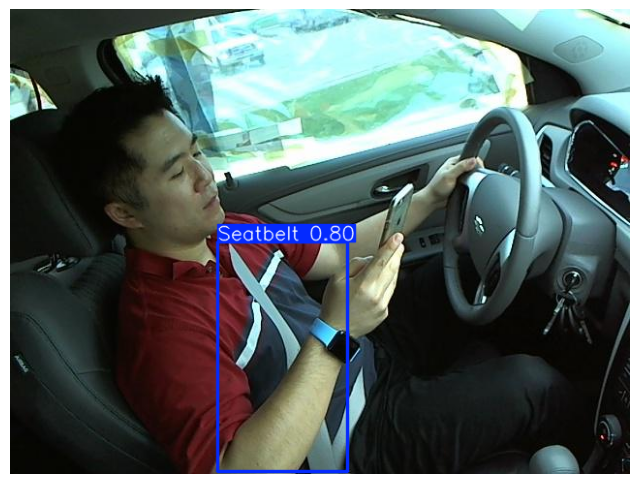

In [ ]:
qqimport cv2
import matplotlib.pyplot as plt

# إجراء التوقع على صورة تجريبية
results = seatbelt_model.predict('/content/img_64937.jpg', conf=0.35)

# عرض الصورة بالصناديق
res_plotted = results[0].plot()
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
import os
import cv2
import pandas as pd
from datetime import datetime, timedelta
from ultralytics import YOLO

# 1. تحميل النماذج
PHONE_MODEL_PATH = '/content/runs/detect/train/weights/best.pt'
BELT_MODEL_PATH = '/content/runs/detect/runs/seatbelt/train/weights/best.pt'

phone_model = YOLO(PHONE_MODEL_PATH)
belt_model = YOLO(BELT_MODEL_PATH)

def process_trip_video(
    video_path,
    trip_id="TRIP-001",
    start_time_str="2026-08-22T03:14:00",
    confidence_threshold=0.30,
    save_annotated_video=True
):
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found at: {video_path}")

    # إعداد قراءة الفيديو
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    start_time = datetime.fromisoformat(start_time_str)

    # إعداد حفظ الفيديو النهائي
    out_video = None
    annotated_video_path = f"/content/annotated_{trip_id}.mp4"
    if save_annotated_video:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out_video = cv2.VideoWriter(annotated_video_path, fourcc, fps, (width, height))

    violations_log = []

    # متغيرات تتبع مخالفة الجوال
    phone_in_violation = False
    phone_cooldown = 0
    phone_cooldown_limit = int(fps * 5)  # فاصل 5 ثوانٍ عند استمرار استخدام الجوال

    # متغيرات تتبع مخالفة عدم ارتداء الحزام (تسجيل مرة واحدة طالما لم يُربط)
    belt_logged_once = False
    unbuckled_consecutive_frames = 0
    belt_trigger_threshold = int(fps * 2)  # التنبيه بعد ثانيتين متواصلتين بدون حزام

    frame_idx = 0

    print(f"Processing video ({total_frames} frames) at {fps:.1f} FPS...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # 2. تشغيل التوقع لكلا النموذجين
        phone_results = phone_model.predict(source=frame, conf=confidence_threshold, verbose=False)
        belt_results = belt_model.predict(source=frame, conf=confidence_threshold, verbose=False)

        phone_classes = [phone_model.names[int(c)] for c in phone_results[0].boxes.cls]
        belt_classes = [belt_model.names[int(c)] for c in belt_results[0].boxes.cls]

        # احتساب التوقيت الفعلي للإطار
        current_timestamp = start_time + timedelta(seconds=(frame_idx / fps))
        timestamp_str = current_timestamp.strftime("%Y-%m-%dT%H:%M:%S")

        # 3. منطق كشف استخدام الجوال
        if 'phone' in phone_classes:
            if not phone_in_violation and phone_cooldown <= 0:
                violations_log.append({
                    'trip_id': trip_id,
                    'violation_type': 'phone_use',
                    'timestamp': timestamp_str
                })
                phone_in_violation = True
                phone_cooldown = phone_cooldown_limit
        else:
            phone_in_violation = False

        if phone_cooldown > 0:
            phone_cooldown -= 1

        # 4. منطق كشف عدم ربط الحزام (تسجيل مرة واحدة فقط حتى يُربط مجدداً)
        has_seatbelt = any('seatbelt' in c.lower() for c in belt_classes)

        if not has_seatbelt:
            unbuckled_consecutive_frames += 1
            if unbuckled_consecutive_frames >= belt_trigger_threshold and not belt_logged_once:
                violations_log.append({
                    'trip_id': trip_id,
                    'violation_type': 'no_seatbelt',
                    'timestamp': timestamp_str
                })
                belt_logged_once = True
        else:
            unbuckled_consecutive_frames = 0
            belt_logged_once = False  # يُعاد التفعيل فقط إذا ربط الحزام ثم فكه مجدداً

        # 5. دمج ورسم الصناديق على الفيديو
        if save_annotated_video and out_video is not None:
            annotated_frame = phone_results[0].plot()
            annotated_frame = belt_results[0].plot(img=annotated_frame)
            out_video.write(annotated_frame)

        frame_idx += 1

    # إغلاق الموارد
    cap.release()
    if out_video is not None:
        out_video.release()

    # تصدير البيانات إلى CSV
    df = pd.DataFrame(violations_log)
    csv_path = f"/content/violations_{trip_id}.csv"
    df.to_csv(csv_path, index=False)

    print(f"Completed analysis for trip: {trip_id}")
    print(f"CSV file saved at: {csv_path}")
    if save_annotated_video:
        print(f"Annotated video saved at: {annotated_video_path}")

    return df

# تشغيل المعالجة
df_violations = process_trip_video(
    video_path='/content/7362606-hd_1920_1080_24fps (1).mp4',
    trip_id='TRIP-001',
    start_time_str='2026-08-22T03:14:00',
    confidence_threshold=0.30
)

print(df_violations)

Processing video (261 frames) at 24.0 FPS...
Completed analysis for trip: TRIP-001
CSV file saved at: /content/violations_TRIP-001.csv
Annotated video saved at: /content/annotated_TRIP-001.mp4
    trip_id violation_type            timestamp
0  TRIP-001      phone_use  2026-08-22T03:14:00
1  TRIP-001    no_seatbelt  2026-08-22T03:14:01


In [ ]:
import glob

all_weights = glob.glob('/content/runs/**/best.pt', recursive=True)
print("الملفات الموجودة فعلياً:")
for idx, path in enumerate(all_weights):
    print(f"[{idx}] {path}")

الملفات الموجودة فعلياً:
[0] /content/runs/detect/runs/seatbelt/train/weights/best.pt
[1] /content/runs/detect/train/weights/best.pt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')